## 1 · Imports

In [1]:
# import scvelo as scv
from multiprocessing import Pool

import anndata as ad
import matplotlib as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib import rcParams

In [2]:
import mudata as mu

In [3]:
from anndata import AnnData
from typing import Optional

# Libraries
import anndata as ad
import matplotlib as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.pyplot import rc_context
from scipy.stats import median_abs_deviation

from functools import partial
import altair as alt
import seaborn as sns
import decoupler as dc
from scipy.sparse import csr_matrix
import os
from pathlib import Path

import mudata as mu
import scanpy as sc
import scirpy as ir
import altair as alt
alt.data_transformers.enable("vegafusion")

import anndata as ad
import numpy as np
import palantir

import numpy as np
import scipy.sparse as sp


## 2 · Data Loading

Load mudata

In [ ]:
mdata = mu.read_h5mu("001_create_mudata.h5mu")

In [ ]:
sc.pl.umap(mdata["gex"], color =["sample_id","condition"])

## 3 · Metadata mapping

Load mudata

In [ ]:
mapping = {
    "10mix_ICI1": "ctrl",
    "10mix_ICI2": "ctrl",
    "11mix_ICI1": "effector",
    "11mix_ICI2": "effector",
    "GF_ICI1": "GF_noICI",
    "GF_ICI2": "GF_noICI",
    "GF_ICI1_plus": "GF",
    "GF_ICI2_plus": "GF",
}

mdata["gex"].obs["group4"] = mdata["gex"].obs["sample_id"].map(mapping)

In [ ]:
mapping = {
    "10mix_ICI1": "ctrl1",
    "10mix_ICI2": "ctrl2",
    "11mix_ICI1": "effector1",
    "11mix_ICI2": "effector2",
    "GF_ICI1": "GF_noICI1",
    "GF_ICI2": "GF_noICI2",
    "GF_ICI1_plus": "GF1",
    "GF_ICI2_plus": "GF2",
}

mdata["gex"].obs["sample_id"] = mdata["gex"].obs["sample_id"].map(mapping)

In [ ]:
desired_order = [
    "effector",
    "ctrl",
    "GF",
    "GF_noici",
]

mdata["gex"].obs["group4"] = pd.Categorical(
    mdata["gex"].obs["group4"], categories=desired_order, ordered=True
)

## 4 · Gene marker ploting


In [ ]:
import scanpy as sc


def plot_marker_umaps(adata, marker_dict, title_prefix):
    for category, genes in marker_dict.items():
        genes = sorted(list(genes))
        genes_present = [g for g in genes if g in adata.var_names]

        if len(genes_present) == 0:
            print(f"No genes found for {category}")
            continue

        print(f"Plotting {category}: {genes_present}")

        sc.pl.umap(
            adata,
            color=genes_present,
            ncols=4,
            cmap="Reds",
            vmax="p99",
            title=[f"{title_prefix} | {category} | {g}" for g in genes_present],
            frameon=False,
        )

In [6]:
gene_markers = {
    "Activated": {
        "Ccl5",
        "Ctla2a",
        "Cd44",
        "Tbx21",
    },
    "Cycling": {"Mki67", "Top2a", "Pclaf"},
    "Effector_memory": {"Gzmk", "Cxcr3"},
    "Exhausted": {
        "Tox","Pdcd1","Havcr2",
    },
    "Stem/Resident_memory": {"Klf2", "Tcf7", "Foxp1", "Lef1", "Bach2", "Sell"},
}

In [ ]:
gene_markers

In [ ]:
plot_marker_umaps(
    adata=mdata["gex"],
    marker_dict=gene_markers,title_prefix = "Gene markers"
)

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["Tcf7", "Slamf6", "Pdcd1"],
    ncols=4,
    cmap="Reds",
    vmax="p99",
    frameon=False,
)

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["Cd44", "Sell"],
    ncols=4,
    cmap="Reds",
    vmax="p99",
    frameon=False,
)

## 5 · Annotation


In [ ]:
# Check unique clusters first (optional, but recommended)
print(mdata["gex"].obs["rna_leiden_05"].unique())

# Create mapping dictionary (adjust numbers if needed)
cluster_annotation = {
    "0": "Activated",
    "1": "Stem/Resident_memory",
    "2": "Effector_memory",
    "3": "Stem/Resident_memory",
    "4": "Exhausted",
    "5": "Activated",
    "6": "Activated",
    "7": "Cycling",
}

# If gex03 is integer instead of string, remove the quotes in dictionary keys
# e.g., 0: "Activated"

# Create new annotation column
mdata["gex"].obs["cell_annotation_05"] = (
    mdata["gex"].obs["rna_leiden_05"].map(cluster_annotation)
)

# Make it categorical (recommended for plotting)
mdata["gex"].obs["cell_annotation_05"] = (
    mdata["gex"].obs["cell_annotation_05"].astype("category")
)

# Verify
print(mdata["gex"].obs[["rna_leiden_05", "cell_annotation_05"]].head())

In [ ]:
sc.pl.umap(
    mdata["gex"], color="cell_annotation_05", frameon=False, legend_loc="on data"
)

## 6 · Dotplot


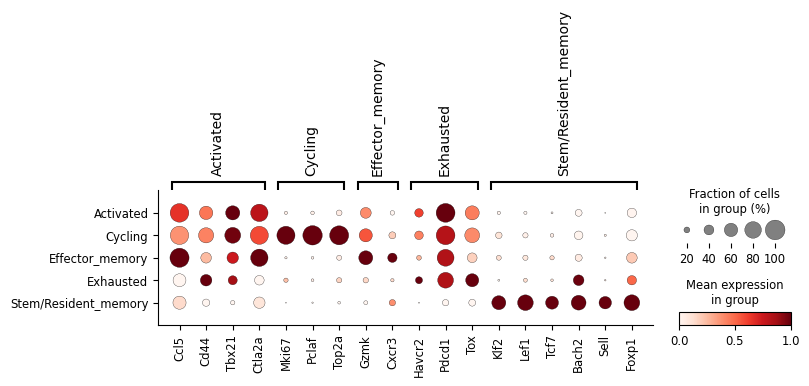

In [7]:
from matplotlib import cm


sc.pl.dotplot(
    mdata["gex"],
    gene_markers,
    groupby="cell_annotation_05",
    standard_scale="var",
    dendrogram=False,
    swap_axes=False,  # ,save="annotation.svg"
)

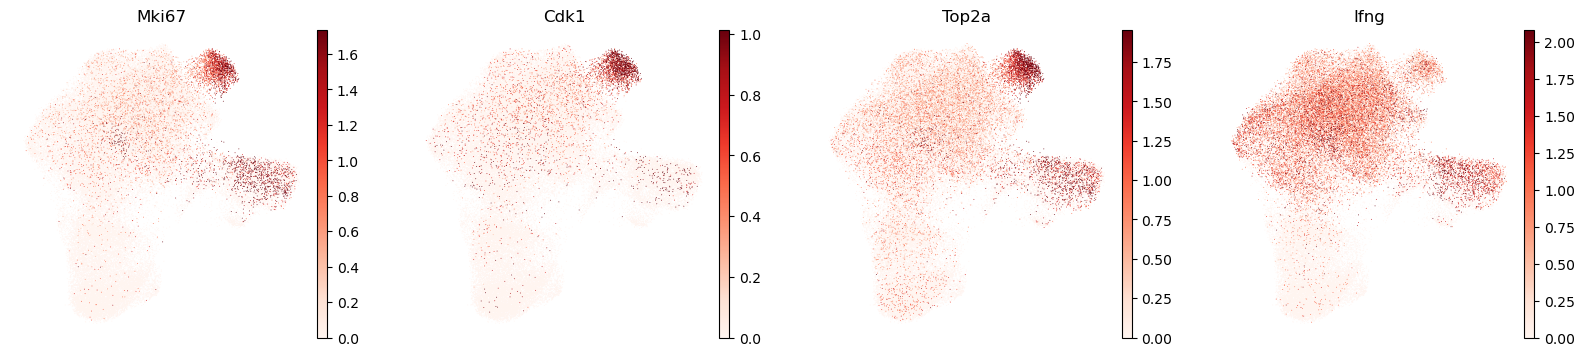

In [8]:
sc.pl.umap(
    mdata["gex"],
    color=["Mki67", "Cdk1", "Top2a","Ifng"],
    ncols=4,
    cmap="Reds",
    vmax="p99",
    frameon=False
)

## 6 · Umap by sample


In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["group4"],
    frameon=True,
    size=5,
    add_outline=False,
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["sample_id"],
    frameon=True,
    size=5,
    add_outline=False,
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["sample_id"],
    frameon=True,
    size=5,
    add_outline=False, groups=["GF_noICI1"],
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["sample_id"],
    frameon=True,
    size=5,
    add_outline=False, groups=["GF_noICI2"],
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["sample_id"],
    frameon=True,
    size=5,
    add_outline=False, groups=["GF1"],
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["sample_id"],
    frameon=True,
    size=5,
    add_outline=False, groups=["GF2"],
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["sample_id"],
    frameon=True,
    size=5,
    add_outline=False, groups=["ctrl1"],
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["sample_id"],
    frameon=True,
    size=5,
    add_outline=False, groups=["ctrl2"],
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["sample_id"],
    frameon=True,
    size=5,
    add_outline=False, groups=["effector1"],
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
sc.pl.umap(
    mdata["gex"],
    color=["sample_id"],
    frameon=True,
    size=5,
    add_outline=False, groups=["effector2"],
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [ ]:
#mdata.write_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/002_annotate_mudata.h5mu")

In [ ]:
#mdata = mu.read_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/002_annotate_mudata.h5mu")

In [ ]:
#adata = mdata["gex"]

In [ ]:
#adata.write_h5ad("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/002_annotate_adata.h5ad")

In [4]:
mdata = mu.read_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/002_annotate_mudata.h5mu")

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/anndata/utils.py:354: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adop

## Cell cycle genes

In [9]:
from __future__ import annotations

import zipfile

import pooch
import scanpy as sc


sc.logging.print_header()

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/session_info2/__init__.py:124: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  and (v := getattr(pkg, "__version__", None))


Package,Version
torch,2.6.0
ipywidgets,8.1.8
palantir,1.4.2
pooch,1.8.2 (v1.8.2)
Component,Info
Python,"3.10.18 | packaged by conda-forge | (main, Jun 4 2025, 14:45:41) [GCC 13.3.0]"
OS,Linux-5.14.0-687.10.1.el9_8.0.1.x86_64-x86_64-with-glibc2.34
CPU,"144 logical CPU cores, x86_64"
GPU,"ID: 0, NVIDIA A40, Driver: 610.43.02, Memory: 46068 MiB"
GPU,"ID: 1, NVIDIA A40, Driver: 610.43.02, Memory: 46068 MiB"


In [10]:
p_zip = pooch.retrieve(
    "https://www.dropbox.com/s/3dby3bjsaf5arrw/cell_cycle_vignette_files.zip?dl=1",
    known_hash="sha256:6557fe2a2761d1550d41edf61b26c6d5ec9b42b4933d56c3161164a595f145ab",
    path="../data",
)

In [11]:
with zipfile.ZipFile(p_zip, "r") as f_zip:
    f_csv = zipfile.Path(f_zip, "nestorawa_forcellcycle_expressionMatrix.txt").open()
    adata = sc.read_csv(f_csv, delimiter="\t").T
    cell_cycle_genes = zipfile.Path(f_zip, "regev_lab_cell_cycle_genes.txt").read_text().splitlines()

In [12]:
s_genes = [x for x in cell_cycle_genes[:43] if x in adata.var_names]
g2m_genes = [x for x in cell_cycle_genes[43:] if x in adata.var_names]
cell_cycle_genes = [*s_genes, *g2m_genes]

In [13]:
import mygene

mg = mygene.MyGeneInfo()

# Query mygene for human genes with HomoloGene data
results = mg.querymany(
    s_genes, scopes='symbol', species='human', fields='homologene', verbose=False
)

mouse_s_genes = []

for item in results:
  found_ortholog = False
  if 'homologene' in item and 'genes' in item['homologene']:
    # Look for the mouse taxon ID (10090 is Mus musculus)
    for gene in item['homologene']['genes']:
      if gene[0] == 10090:  # Taxon ID for Mouse
        # Fetch official mouse symbol via gene ID
        mouse_info = mg.getgene(gene[1], fields='symbol')
        if mouse_info and 'symbol' in mouse_info:
          mouse_s_genes.append(mouse_info['symbol'])
          found_ortholog = True
          break

  # Fallback to string capitalization if no HomoloGene ortholog found
  if not found_ortholog:
    mouse_s_genes.append(item['query'].capitalize())

print(mouse_s_genes)

2026-08-06 10:48:15 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-06 10:48:15 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-06 10:48:16 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-08-06 10:48:17 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-06 10:48:17 | [INFO] HTTP Request: GET https://mygene.info/v3/gene/17218?fields=symbol "HTTP/1.1 200 OK"
2026-08-06 10:48:17 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-06 10:48:18 | [INFO] HTTP Request: GET https://mygene.info/v3/gene/18538?fields=symbol "HTTP/1.1 200 OK"
2026-08-06 10:48:18 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-06 10:48:18 | [INFO] HTTP Request: GET https://mygene.info/v3/gene/22171?fields=symbol "HTTP/1.1 200 OK"
2026-08-06 10:48:18 | [WA

['Mcm5', 'Pcna', 'Tyms', 'Fen1', 'Mcm2', 'Mcm4', 'Rrm1', 'Ung', 'Gins2', 'Mcm6', 'Cdca7', 'Dtl', 'Prim1', 'Uhrf1', 'Hells', 'Rfc2', 'Rpa2', 'Nasp', 'Rad51ap1', 'Wdr76', 'Slbp', 'Ccne2', 'Ubr7', 'Pold3', 'Msh2', 'Atad2', 'Rad51', 'Rrm2', 'Cdc45', 'Cdc6', 'Exo1', 'Tipin', 'Dscc1', 'Blm', 'Casp8ap2', 'Usp1', 'Clspn', 'Pola1', 'Chaf1b', 'Brip1', 'E2f8']


In [14]:
import mygene

mg = mygene.MyGeneInfo()

# Query mygene for human genes with HomoloGene data
results = mg.querymany(
    g2m_genes, scopes='symbol', species='human', fields='homologene', verbose=False
)

mouse_g2m_genes = []

for item in results:
  found_ortholog = False
  if 'homologene' in item and 'genes' in item['homologene']:
    # Look for the mouse taxon ID (10090 is Mus musculus)
    for gene in item['homologene']['genes']:
      if gene[0] == 10090:  # Taxon ID for Mouse
        # Fetch official mouse symbol via gene ID
        mouse_info = mg.getgene(gene[1], fields='symbol')
        if mouse_info and 'symbol' in mouse_info:
          mouse_g2m_genes.append(mouse_info['symbol'])
          found_ortholog = True
          break

  # Fallback to string capitalization if no HomoloGene ortholog found
  if not found_ortholog:
    mouse_g2m_genes.append(item['query'].capitalize())

print(mouse_g2m_genes)

2026-08-06 10:48:26 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-06 10:48:26 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-06 10:48:27 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-08-06 10:48:28 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-06 10:48:28 | [INFO] HTTP Request: GET https://mygene.info/v3/gene/97165?fields=symbol "HTTP/1.1 200 OK"
2026-08-06 10:48:28 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-06 10:48:28 | [INFO] HTTP Request: GET https://mygene.info/v3/gene/12534?fields=symbol "HTTP/1.1 200 OK"
2026-08-06 10:48:28 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-06 10:48:28 | [INFO] HTTP Request: GET https://mygene.info/v3/gene/108907?fields=symbol "HTTP/1.1 200 OK"
2026-08-06 10:48:28 | [W

['Hmgb2', 'Cdk1', 'Nusap1', 'Ube2c', 'Birc5', 'Tpx2', 'Top2a', 'Ndc80', 'Cks2', 'Nuf2', 'Cks1b', 'Mki67', 'Tmpo', 'Cenpf', 'Tacc3', 'Fam64a', 'Smc4', 'Ccnb2', 'Ckap2l', 'Ckap2', 'Aurkb', 'Bub1', 'Kif11', 'Anp32e', 'Tubb4b', 'Gtse1', 'Kif20b', 'Hjurp', 'Cdca3', 'Hn1', 'Cdc20', 'Ttk', 'Cdc25c', 'Kif2c', 'Rangap1', 'Ncapd2', 'Dlgap5', 'Cdca2', 'Cdca8', 'Ect2', 'Kif23', 'Hmmr', 'Aurka', 'Psrc1', 'Anln', 'Lbr', 'Ckap5', 'Cenpe', 'Ctcf', 'Nek2', 'G2e3', 'Gas2l3', 'Cbx5', 'Cenpa']


In [15]:
import mygene

mg = mygene.MyGeneInfo()

# Query mygene for human genes with HomoloGene data
results = mg.querymany(
    cell_cycle_genes, scopes='symbol', species='human', fields='homologene', verbose=False
)

mouse_cell_cycle_genes = []

for item in results:
  found_ortholog = False
  if 'homologene' in item and 'genes' in item['homologene']:
    # Look for the mouse taxon ID (10090 is Mus musculus)
    for gene in item['homologene']['genes']:
      if gene[0] == 10090:  # Taxon ID for Mouse
        # Fetch official mouse symbol via gene ID
        mouse_info = mg.getgene(gene[1], fields='symbol')
        if mouse_info and 'symbol' in mouse_info:
          mouse_cell_cycle_genes.append(mouse_info['symbol'])
          found_ortholog = True
          break

  # Fallback to string capitalization if no HomoloGene ortholog found
  if not found_ortholog:
    mouse_cell_cycle_genes.append(item['query'].capitalize())

print(mouse_cell_cycle_genes)

2026-08-06 10:48:39 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-06 10:48:39 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-06 10:48:39 | [INFO] HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
2026-08-06 10:48:40 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-06 10:48:41 | [INFO] HTTP Request: GET https://mygene.info/v3/gene/17218?fields=symbol "HTTP/1.1 200 OK"
2026-08-06 10:48:41 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-06 10:48:41 | [INFO] HTTP Request: GET https://mygene.info/v3/gene/18538?fields=symbol "HTTP/1.1 200 OK"
2026-08-06 10:48:41 | [WARNING] Input sequence provided is already in string format. No operation performed
2026-08-06 10:48:41 | [INFO] HTTP Request: GET https://mygene.info/v3/gene/22171?fields=symbol "HTTP/1.1 200 OK"
2026-08-06 10:48:41 | [WA

['Mcm5', 'Pcna', 'Tyms', 'Fen1', 'Mcm2', 'Mcm4', 'Rrm1', 'Ung', 'Gins2', 'Mcm6', 'Cdca7', 'Dtl', 'Prim1', 'Uhrf1', 'Hells', 'Rfc2', 'Rpa2', 'Nasp', 'Rad51ap1', 'Wdr76', 'Slbp', 'Ccne2', 'Ubr7', 'Pold3', 'Msh2', 'Atad2', 'Rad51', 'Rrm2', 'Cdc45', 'Cdc6', 'Exo1', 'Tipin', 'Dscc1', 'Blm', 'Casp8ap2', 'Usp1', 'Clspn', 'Pola1', 'Chaf1b', 'Brip1', 'E2f8', 'Hmgb2', 'Cdk1', 'Nusap1', 'Ube2c', 'Birc5', 'Tpx2', 'Top2a', 'Ndc80', 'Cks2', 'Nuf2', 'Cks1b', 'Mki67', 'Tmpo', 'Cenpf', 'Tacc3', 'Fam64a', 'Smc4', 'Ccnb2', 'Ckap2l', 'Ckap2', 'Aurkb', 'Bub1', 'Kif11', 'Anp32e', 'Tubb4b', 'Gtse1', 'Kif20b', 'Hjurp', 'Cdca3', 'Hn1', 'Cdc20', 'Ttk', 'Cdc25c', 'Kif2c', 'Rangap1', 'Ncapd2', 'Dlgap5', 'Cdca2', 'Cdca8', 'Ect2', 'Kif23', 'Hmmr', 'Aurka', 'Psrc1', 'Anln', 'Lbr', 'Ckap5', 'Cenpe', 'Ctcf', 'Nek2', 'G2e3', 'Gas2l3', 'Cbx5', 'Cenpa']


In [16]:
sc.pp.filter_cells(mdata["gex"], min_genes=200)
sc.pp.filter_genes(mdata["gex"], min_cells=3)
sc.pp.normalize_total(mdata["gex"], target_sum=1e4)

In [17]:
sc.pp.log1p(mdata["gex"])

adata.X seems to be already log-transformed.


In [18]:
sc.tl.score_genes_cell_cycle(mdata["gex"], s_genes=mouse_s_genes, g2m_genes=mouse_g2m_genes)

genes are not in var_names and ignored: Index(['Fam64a', 'Hn1'], dtype='object')


In [19]:
mdata["gex"].obs

,adata_name,condition,batch_id,sample_id,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mito,...,pct_counts_hb,rna_leiden,rna_leiden_05,gex03,group4,cell_annotation_05,n_genes,S_score,G2M_score,phase
10mix-ICI1_AAACCTGAGAGCCTAG-1,adata_10mix_ICI1,10mix,ICI1,10mix_ICI1,2513,7.829630,7829.0,8.965718,13.897049,70.0,...,0.0,4,0,0,ctrl,Activated,2513,-0.055806,-0.183790,G1
10mix-ICI1_AAACCTGAGATGTGGC-1,adata_10mix_ICI1,10mix,ICI1,10mix_ICI1,3022,8.014005,11793.0,9.375346,17.001611,150.0,...,0.0,1,2,0,ctrl,Effector_memory,3022,-0.145641,-0.109822,G1
10mix-ICI1_AAACCTGAGCCACGTC-1,adata_10mix_ICI1,10mix,ICI1,10mix_ICI1,596,6.391917,1105.0,7.008505,30.588235,108.0,...,0.0,12,3,1,ctrl,Stem/Resident_memory,596,0.007996,-0.117848,S
10mix-ICI1_AAACCTGAGGCTCTTA-1,adata_10mix_ICI1,10mix,ICI1,10mix_ICI1,1470,7.293698,3882.0,8.264363,19.500258,100.0,...,0.0,2,3,1,ctrl,Stem/Resident_memory,1470,-0.227974,-0.084040,G1
10mix-ICI1_AAACCTGAGGGCACTA-1,adata_10mix_ICI1,10mix,ICI1,10mix_ICI1,2209,7.700748,7992.0,8.986321,18.018018,72.0,...,0.0,1,2,2,ctrl,Effector_memory,2209,-0.154854,-0.276425,G1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GF-ICI2-plus_TTTGTCATCCCTTGCA-1,adata_GF_ICI2_plus,GF,ICI2,GF_ICI2_plus,2108,7.653969,6218.0,8.735365,15.937601,136.0,...,0.0,0,0,0,GF,Activated,2108,-0.189304,-0.078499,G1
GF-ICI2-plus_TTTGTCATCGTTGCCT-1,adata_GF_ICI2_plus,GF,ICI2,GF_ICI2_plus,4821,8.480944,25856.0,10.160336,14.948175,493.0,...,0.0,10,0,0,GF,Activated,4820,0.213663,-0.069639,S
GF-ICI2-plus_TTTGTCATCTAACTGG-1,adata_GF_ICI2_plus,GF,ICI2,GF_ICI2_plus,1685,7.430114,3886.0,8.265393,13.767370,73.0,...,0.0,1,1,2,GF,Stem/Resident_memory,1685,-0.096517,-0.091295,G1
GF-ICI2-plus_TTTGTCATCTCTGTCG-1,adata_GF_ICI2_plus,GF,ICI2,GF_ICI2_plus,2101,7.650645,6973.0,8.849944,17.453033,170.0,...,0.0,1,2,2,GF,Effector_memory,2101,-0.194325,-0.247427,G1


... storing 'phase' as categorical


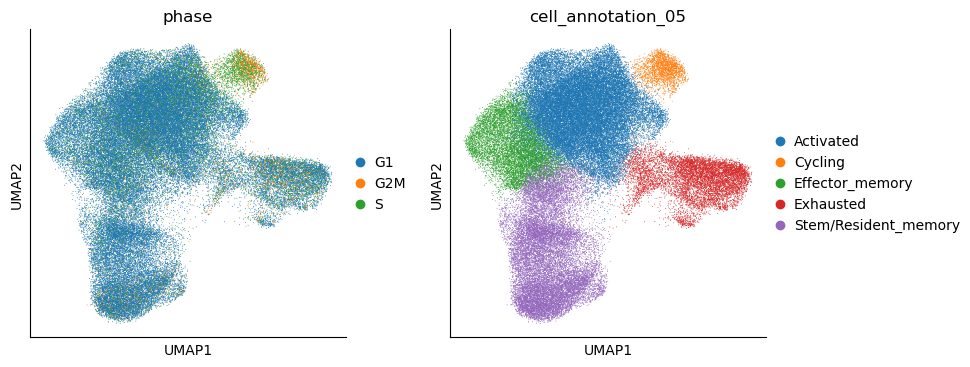

In [20]:
sc.pl.umap(mdata["gex"], color = ["phase","cell_annotation_05"])

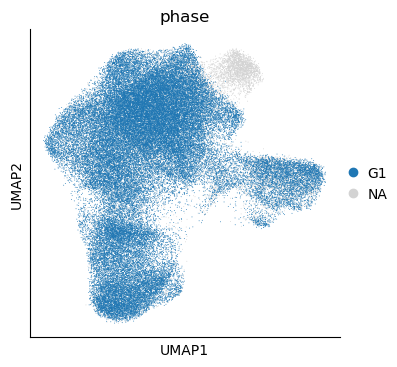

In [21]:
sc.pl.umap(mdata["gex"], color = "phase", groups="G1")

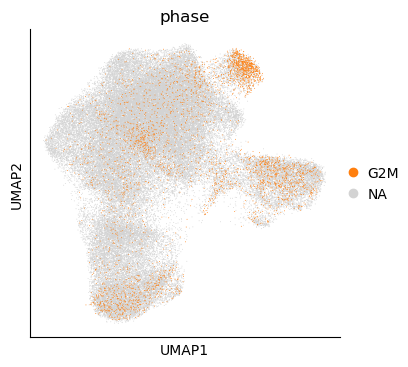

In [22]:
sc.pl.umap(mdata["gex"], color = "phase", groups="G2M")

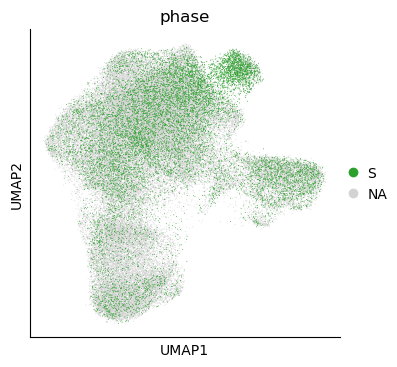

In [23]:
sc.pl.umap(mdata["gex"], color = "phase", groups="S")

Genes missing from dataset (2): {'Fam64a', 'Hn1'}


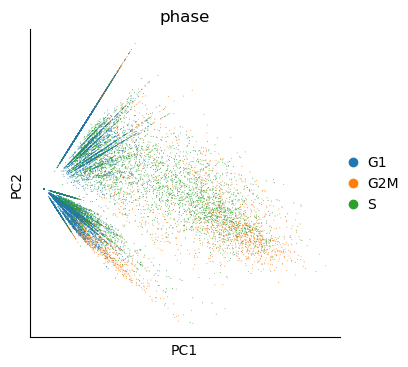

In [24]:
# 1. Filter to keep only cell cycle genes present in your GEX dataset
valid_cc_genes = [g for g in mouse_cell_cycle_genes if g in mdata["gex"].var_names]

# Print missing genes (optional, to verify which were dropped)
missing_genes = set(mouse_cell_cycle_genes) - set(valid_cc_genes)
print(f"Genes missing from dataset ({len(missing_genes)}): {missing_genes}")

# 2. Subset the AnnData object using the validated list
adata_cc_genes = mdata["gex"][:, valid_cc_genes].copy()

# 3. Run PCA
sc.tl.pca(adata_cc_genes)
sc.pl.pca(adata_cc_genes, color="phase")

In [25]:
sc.pp.regress_out(mdata["gex"], ["S_score", "G2M_score"])

Genes missing from dataset (2): {'Fam64a', 'Hn1'}


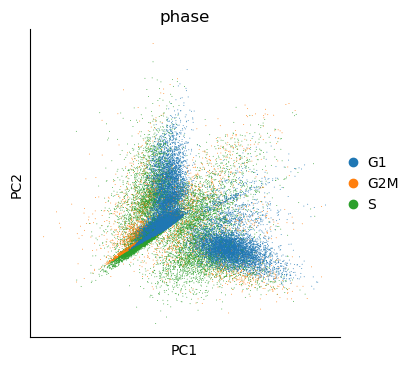

In [26]:
# 1. Filter to keep only cell cycle genes present in your GEX dataset
valid_cc_genes = [g for g in mouse_cell_cycle_genes if g in mdata["gex"].var_names]

# Print missing genes (optional, to verify which were dropped)
missing_genes = set(mouse_cell_cycle_genes) - set(valid_cc_genes)
print(f"Genes missing from dataset ({len(missing_genes)}): {missing_genes}")

# 2. Subset the AnnData object using the validated list
adata_cc_genes = mdata["gex"][:, valid_cc_genes].copy()

# 3. Run PCA
sc.tl.pca(adata_cc_genes)
sc.pl.pca(adata_cc_genes, color="phase")

In [124]:
import numpy as np

# 1. Reference the GEX AnnData object
gex = mdata["gex"]

# 2. Extract Ifng expression array safely (handles sparse or dense matrices)
#ifng_expr = gex[:, "Ifng"].X.toarray().flatten() if hasattr(gex.X, "toarray") else gex[:, "Ifng"].X.flatten()

# 3. Combine conditions: (S or G2M phase) AND (Ifng > 0)
cycling_mask = gex.obs["phase"].isin(["S", "G2M"]) #& (ifng_expr > 0)

# 4. Subset the AnnData or MuData object
cycling = gex[cycling_mask].copy()

In [125]:
mdata["gex"]

AnnData object with n_obs × n_vars = 72579 × 17581
    obs: 'adata_name', 'condition', 'batch_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05', 'n_genes', 'S_score', 'G2M_score', 'phase'
    var: 'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
    uns: 'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'rna_leiden', 'rna_leiden_05', 'r

In [126]:
# 5. Recompute Neighborhood Graph
# Set n_pcs <= min(30, n_cells - 1) if your subset is very small
sc.pp.neighbors(cycling, n_neighbors=15, n_pcs=30)

# 6. Recompute UMAP Embedding
sc.tl.umap(cycling)

# 7. Recompute Clustering (Adjust resolution as needed: lower = fewer clusters)
sc.tl.leiden(cycling, resolution=0.5, key_added="leiden")



In [110]:
cycling

AnnData object with n_obs × n_vars = 5622 × 17581
    obs: 'adata_name', 'condition', 'batch_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05', 'n_genes', 'S_score', 'G2M_score', 'phase', 'leiden'
    var: 'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
    uns: 'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'rna_leiden', 'rna_leide

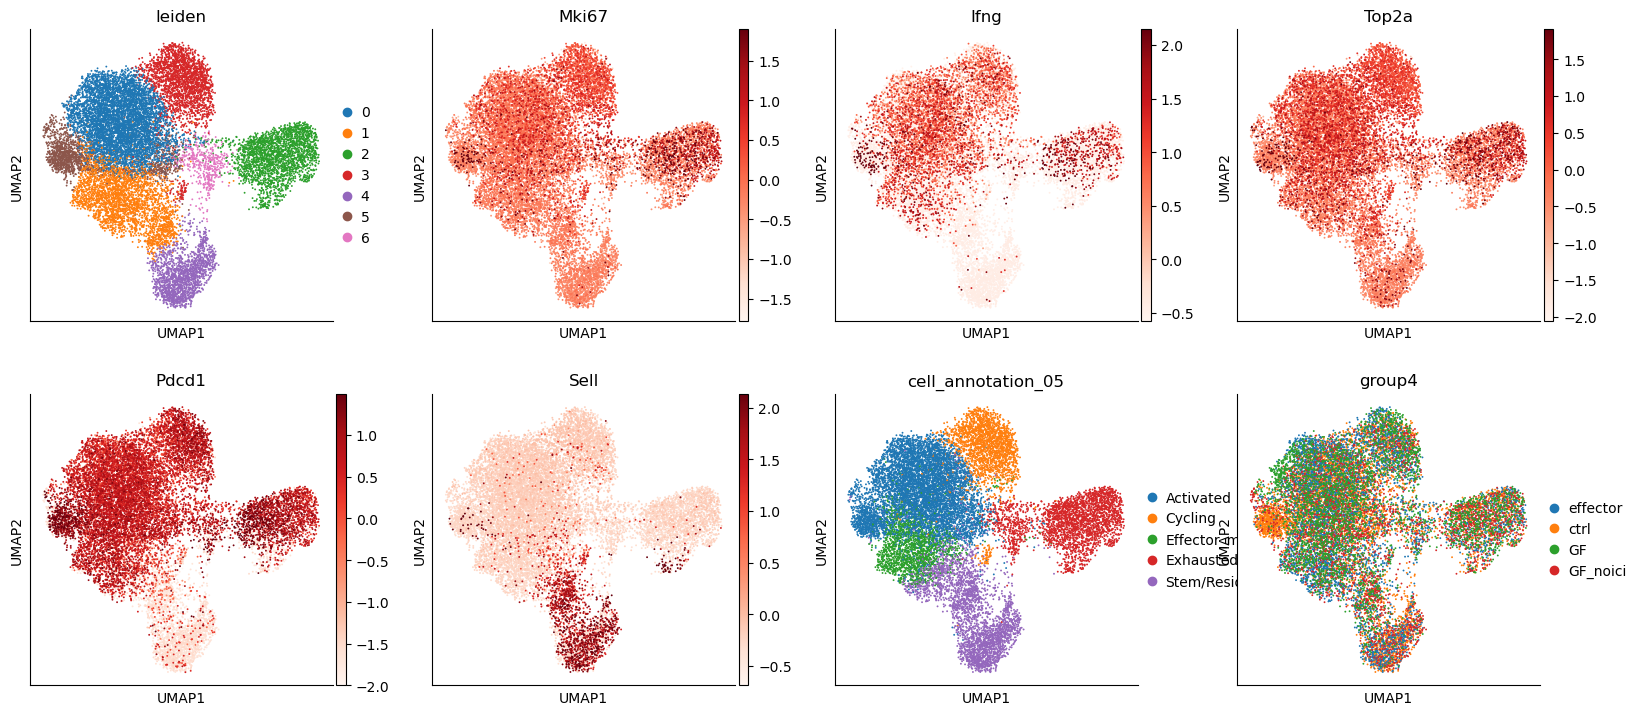

In [127]:
# 8. Visualize the new embedding
sc.pl.umap(cycling, color=["leiden","Mki67", "Ifng","Top2a","Pdcd1","Sell","cell_annotation_05","group4"], cmap="Reds", vmax="p99")

In [130]:
cycling

AnnData object with n_obs × n_vars = 16440 × 17581
    obs: 'adata_name', 'condition', 'batch_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05', 'n_genes', 'S_score', 'G2M_score', 'phase', 'leiden'
    var: 'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
    uns: 'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'rna_leiden', 'rna_leid

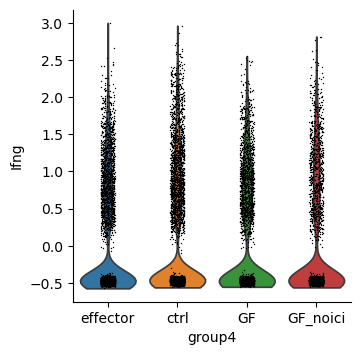

In [136]:
sc.pl.violin(cycling, ["Ifng"], groupby="group4")

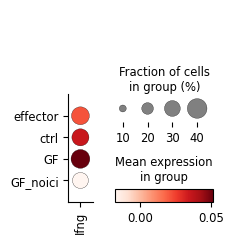

In [135]:
sc.pl.dotplot(cycling,["Ifng"], groupby="group4")